In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
import math
import time

plt.rcParams['figure.figsize'] = (16, 16)

In [2]:
def codes(m, n):
    l = 0
    codes = []
    while l < m**n:
        k = l
        j = n - 1
        expan = []
        while j >= 0:
            expan.append(k // (m**j))
            if k // (m**j) != 0:
                k = k % (m**j)
            j -= 1
        l += 1
        codes.append(expan)
    return np.array(codes)

Iteration 0 took 0.0025216999999884138 seconds.
Iteration 1 took 0.014758999999997968 seconds.
Iteration 2 took 0.03297770000000355 seconds.
Iteration 3 took 0.083615199999997 seconds.
Iteration 4 took 0.24668249999999148 seconds.
Iteration 5 took 0.610137299999991 seconds.
Iteration 6 took 1.5712785999999994 seconds.
Iteration 7 took 5.199480300000005 seconds.
Iteration 8 took 15.946197299999994 seconds.


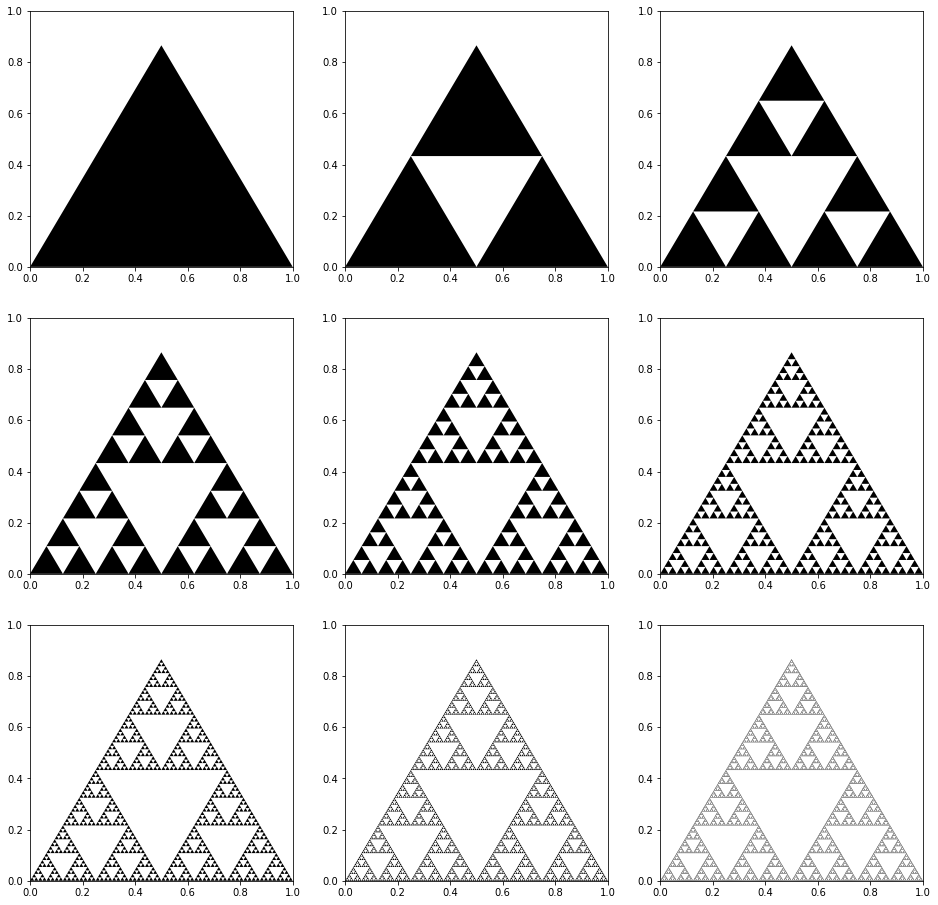

The whole cell took 22.525290799999993 seconds.


In [6]:
def f(array, j):
    if j == 0:
        return 0.5*array
    elif j == 1:
        return 0.5*(array + [1, 0])
    else:
        return 0.5*(array + [0.5, np.sqrt(3)/2])

fig, ax = plt.subplots(nrows = 3, ncols = 3)
#ax.set_xlim([0, 1])
#ax.set_ylim([0, 1])

start = time.perf_counter()

for j in range(9):
    for code in codes(3, j):
        y = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])    
        for i in code:
            y = f(y, i)
        ax[j // 3, j % 3].add_patch(Polygon(y, facecolor = 'k'))
    end = time.perf_counter()
    print('Iteration ' + str(j) + ' took ' + str(end - start) + ' seconds.')
        
plt.show()
end = time.perf_counter()
print('The whole cell took ' + str(end - start) + ' seconds.')

Iteration 0 took 0.0032778000000064367 seconds.
Iteration 1 took 0.012452899999999545 seconds.
Iteration 2 took 0.03266039999999748 seconds.
Iteration 3 took 0.09089249999999538 seconds.
Iteration 4 took 0.28185229999999706 seconds.
Iteration 5 took 1.0652411000000086 seconds.
Iteration 6 took 3.9539001999999925 seconds.
Iteration 7 took 10.88898789999999 seconds.
Iteration 8 took 41.2952023 seconds.


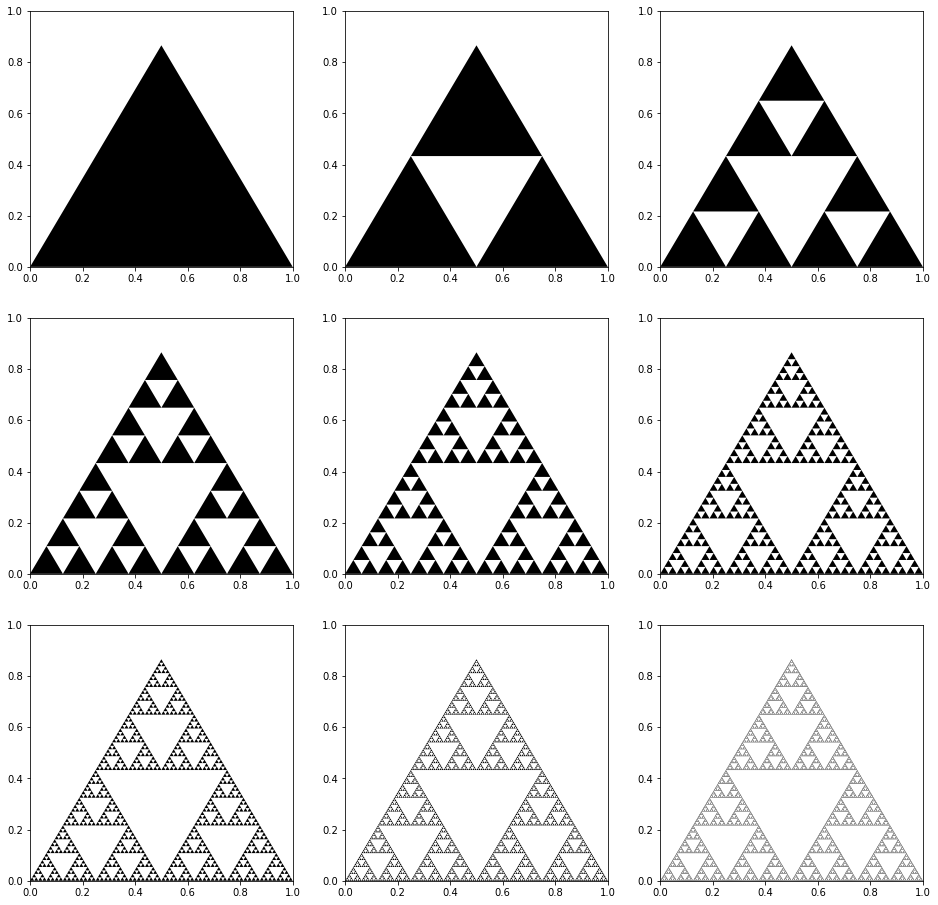

The whole cell took 49.870188600000006 seconds.


In [7]:
import matplotlib as mpl

fig, ax = plt.subplots(nrows = 3, ncols = 3)
#ax.set_xlim([0, 1])
#ax.set_ylim([0, 1])

t0 = mpl.transforms.Affine2D().scale(0.5)
t1 = mpl.transforms.Affine2D().translate(1, 0) + mpl.transforms.Affine2D().scale(0.5)
t2 = mpl.transforms.Affine2D().translate(0.5, np.sqrt(3)/2) + mpl.transforms.Affine2D().scale(0.5)

ifsTransforms = [t0, t1, t2]

clicks = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])

start = time.perf_counter()

for j in range(9):
    for code in codes(len(ifsTransforms), j):
        y = mpl.patches.Polygon(clicks, facecolor = 'k')
        t = mpl.transforms.IdentityTransform()
        for i in code:
            t += ifsTransforms[i]
        t += ax[j // 3, j % 3].transData
        y.set_transform(t)
        ax[j // 3, j % 3].add_patch(y)
    end = time.perf_counter()
    print('Iteration ' + str(j) + ' took ' + str(end - start) + ' seconds.')
        
plt.show()
end = time.perf_counter()
print('The whole cell took ' + str(end - start) + ' seconds.')

Iteration 0 took 0.0016380000000140171 seconds.
Iteration 1 took 0.007438499999977921 seconds.
Iteration 2 took 0.020354600000018763 seconds.
Iteration 3 took 0.054586200000017016 seconds.
Iteration 4 took 0.1586945999999898 seconds.
Iteration 5 took 0.5006581999999753 seconds.
Iteration 6 took 1.5790089000000194 seconds.
Iteration 7 took 6.944766300000026 seconds.
Iteration 8 took 18.593107099999997 seconds.


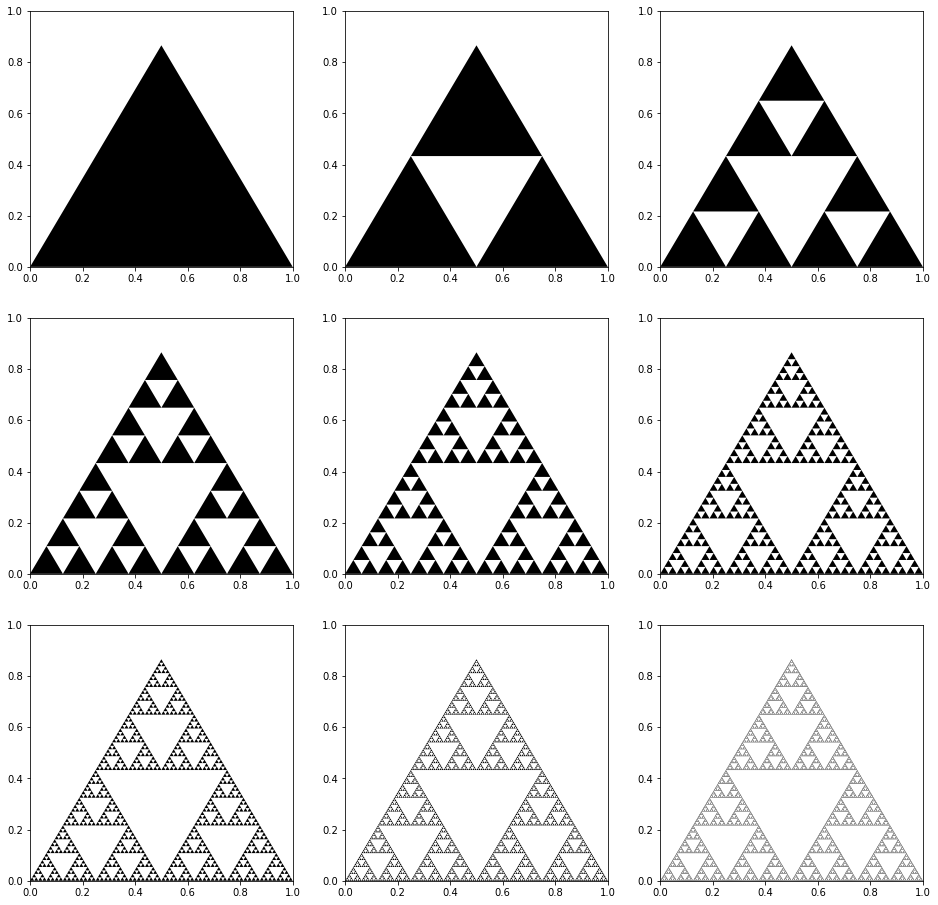

The whole cell took 25.8279996 seconds.


In [9]:
#This method wins!

import matplotlib as mpl

#Input the desired number of iterations

fig, ax = plt.subplots(nrows = 3, ncols = 3)

#Input the axis limits

for i in range(9):
    ax[i // 3, i % 3].set_xlim([0, 1])
    ax[i // 3, i % 3].set_ylim([0, 1])

#Input the IFS functions    

t0 = mpl.transforms.Affine2D().scale(0.5)
t1 = mpl.transforms.Affine2D().translate(1, 0) + mpl.transforms.Affine2D().scale(0.5)
t2 = mpl.transforms.Affine2D().translate(0.5, np.sqrt(3)/2) + mpl.transforms.Affine2D().scale(0.5)

ifsTransforms = [t0, t1, t2]
m = len(ifsTransforms)

#Input the vertices for the starting set

clicks = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])
color = 'k'

################################################################

start = time.perf_counter()

for j in range(9):
    for code in codes(m, j):
        t = mpl.transforms.IdentityTransform()
        for i in code:
            t += ifsTransforms[i]
        ax[j // 3, j % 3].add_patch(mpl.patches.Polygon(t.transform(clicks), facecolor = color))
    end = time.perf_counter()
    print('Iteration ' + str(j) + ' took ' + str(end - start) + ' seconds.')
        
plt.show()
end = time.perf_counter()
print('The whole cell took ' + str(end - start) + ' seconds.')

Iteration 0 took 0.00193319999925734 seconds.
Iteration 1 took 0.007792599999447702 seconds.
Iteration 2 took 0.022197599999344675 seconds.
Iteration 3 took 0.06530299999940326 seconds.
Iteration 4 took 0.22902020000037737 seconds.
Iteration 5 took 0.692320699999982 seconds.
Iteration 6 took 2.4756739000004018 seconds.
Iteration 7 took 6.614252800000031 seconds.
Iteration 8 took 21.62551220000023 seconds.


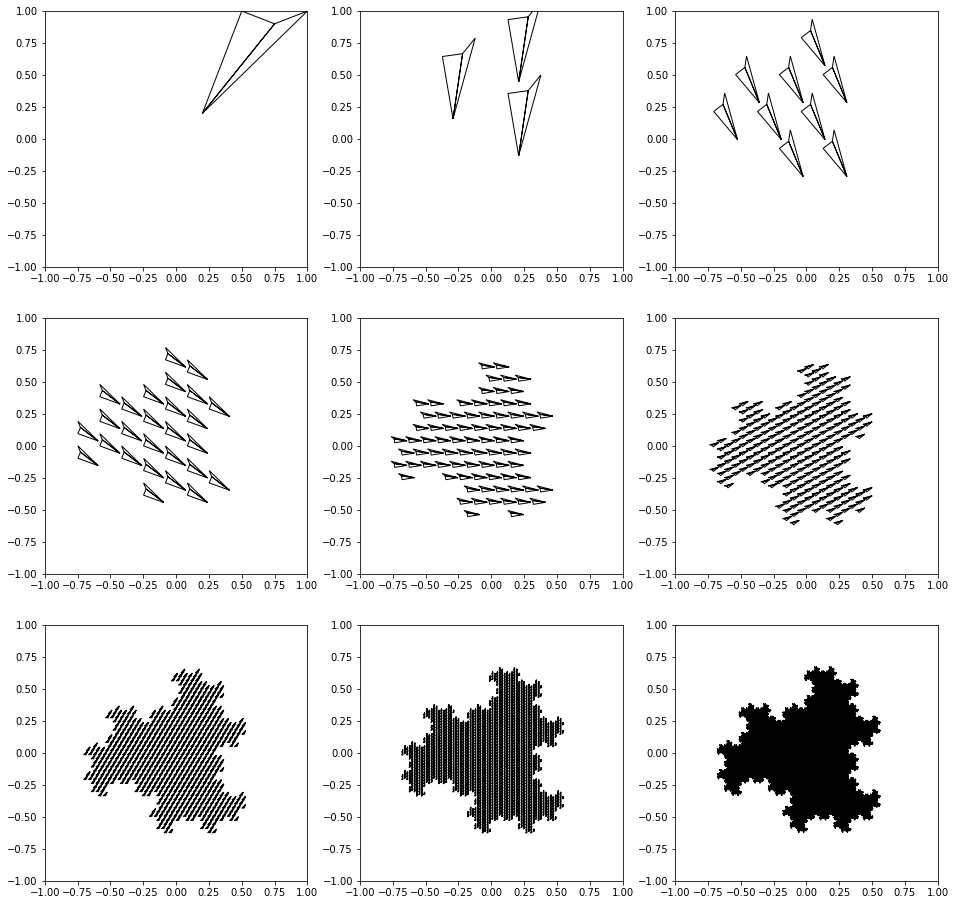

The whole cell took 30.805641199998718 seconds.


In [45]:
import matplotlib as mpl

fig, ax = plt.subplots(nrows = 3, ncols = 3)

for i in range(9):
    ax[i // 3, i % 3].set_xlim([-1, 1])
    ax[i // 3, i % 3].set_ylim([-1, 1])

clicks = np.array([[0.2, 0.2], [1, 1], [0.75, 0.9], [0.2, 0.2], [0.75, 0.9], [0.5, 1]])

lamda = 1/np.sqrt(3)

t0 = mpl.transforms.Affine2D().rotate(np.pi/6) + mpl.transforms.Affine2D().scale(lamda) + mpl.transforms.Affine2D().translate(-1/3, 0)
t1 = mpl.transforms.Affine2D().rotate(np.pi/6) + mpl.transforms.Affine2D().scale(lamda) + mpl.transforms.Affine2D().translate(0.5*(1/3), (np.sqrt(3)/2)*(1/3))
t2 = mpl.transforms.Affine2D().rotate(np.pi/6) + mpl.transforms.Affine2D().scale(lamda) + mpl.transforms.Affine2D().translate(0.5*(1/3), -(np.sqrt(3)/2)*(1/3))

ifsTransforms = [t0, t1, t2]
m = len(ifsTransforms)  

start = time.perf_counter()

for j in range(9):
    for code in codes(m, j):
        t = mpl.transforms.IdentityTransform()
        for i in code:
            t += ifsTransforms[i]
        ax[j // 3, j % 3].add_patch(mpl.patches.Polygon(t.transform(clicks), facecolor = 'w', edgecolor = 'k'))
    end = time.perf_counter()
    print('Iteration ' + str(j) + ' took ' + str(end - start) + ' seconds.')

plt.show()
end = time.perf_counter()
print('The whole cell took ' + str(end - start) + ' seconds.')

Iteration 0 took 0.001901799999927789 seconds.
Iteration 1 took 0.005991999999992004 seconds.
Iteration 2 took 0.013307299999951283 seconds.
Iteration 3 took 0.02670269999998709 seconds.
Iteration 4 took 0.052699500000017 seconds.
Iteration 5 took 0.1254570999999487 seconds.
Iteration 6 took 0.2667744999999968 seconds.
Iteration 7 took 0.5041960999999446 seconds.
Iteration 8 took 1.1441659999999274 seconds.
Iteration 9 took 2.0737739999999576 seconds.
Iteration 10 took 4.144193799999925 seconds.
Iteration 11 took 8.28393589999996 seconds.


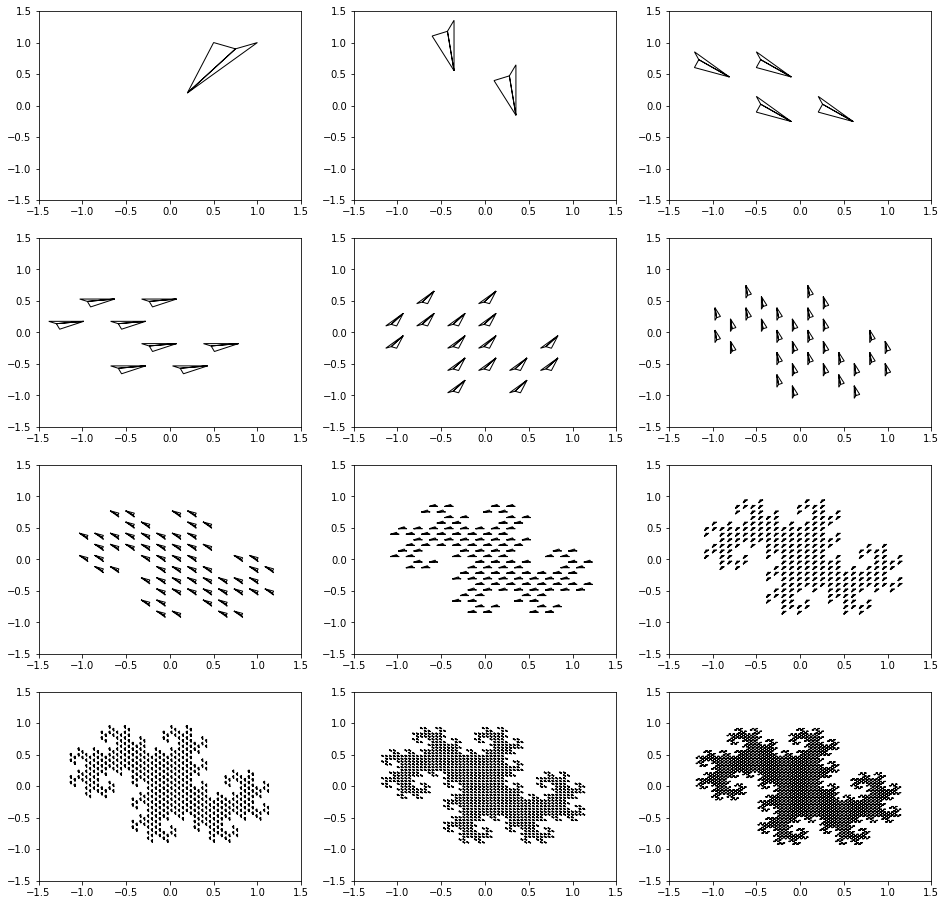

The whole cell took 13.51296549999995 seconds.


In [10]:
import matplotlib as mpl

fig, ax = plt.subplots(nrows = 4, ncols = 3)

for i in range(12):
    ax[i // 3, i % 3].set_xlim([-1.5, 1.5])
    ax[i // 3, i % 3].set_ylim([-1.5, 1.5])

clicks = np.array([[0.2, 0.2], [1, 1], [0.75, 0.9], [0.2, 0.2], [0.75, 0.9], [0.5, 1]])

lamda = 1/np.sqrt(2)

t0 = mpl.transforms.Affine2D().rotate(np.pi/4) + mpl.transforms.Affine2D().translate(-0.5, 0.5) + mpl.transforms.Affine2D().scale(lamda)
t1 = mpl.transforms.Affine2D().rotate(np.pi/4) + mpl.transforms.Affine2D().translate(0.5, -0.5) + mpl.transforms.Affine2D().scale(lamda)

ifsTransforms = [t0, t1]
m = len(ifsTransforms)    
start = time.perf_counter()

for j in range(12):
    for code in codes(m, j):
        t = mpl.transforms.IdentityTransform()
        for i in code:
            t += ifsTransforms[i]
        ax[j // 3, j % 3].add_patch(mpl.patches.Polygon(t.transform(clicks), facecolor = 'w', edgecolor = 'k'))
    end = time.perf_counter()
    print('Iteration ' + str(j) + ' took ' + str(end - start) + ' seconds.')

plt.show()
end = time.perf_counter()
print('The whole cell took ' + str(end - start) + ' seconds.')